<a href="https://colab.research.google.com/github/mipaillafil/ejercicio_clusters/blob/main/2_2_sesion_1_cluster_y_ejemplo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**2.2 Sesión 1 - Cluster y ejemplo**

##1.- Importar Librerias

In [48]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

##2.- Cargar Dataset

In [58]:
#Cargar datos reales
url = "https://raw.githubusercontent.com/mipaillafil/ejercicio_clusters/main/Mall_Customers.csv"
df = pd.read_csv(url)
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


##3.- Encontrar número óptimo de grupos

In [50]:
# Seleccionamos las columnas: Ingreso Anual y Puntuación Gasto
X_real = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(df.head()) # Ver los primeros 5 clientes

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [51]:
inercia = [] # Lista para guardar la "tensión" de los grupos
# Probamos con K desde 1 hasta 10
for k in range(1, 11):
  model = KMeans(n_clusters=k, random_state=42)
  model.fit(X_real)
  inercia.append(model.inertia_) # La inercia mide qué tan lejos están los puntos de sus centros

##4.- Graficar Resultados

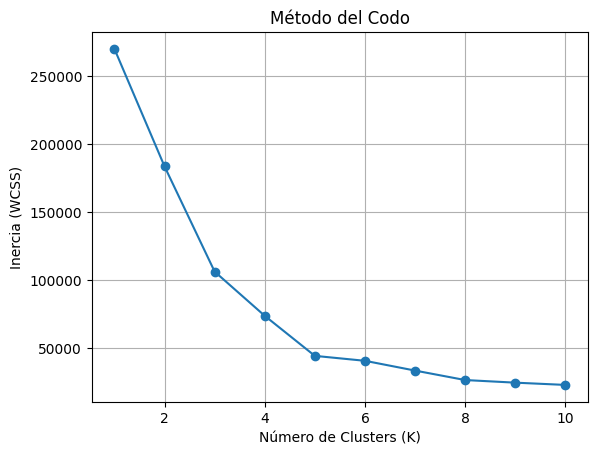

In [52]:
plt.plot(range(1, 11), inercia, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo')
plt.grid()
plt.show()

## 5.- Aplicar K-Means a Datos Reales

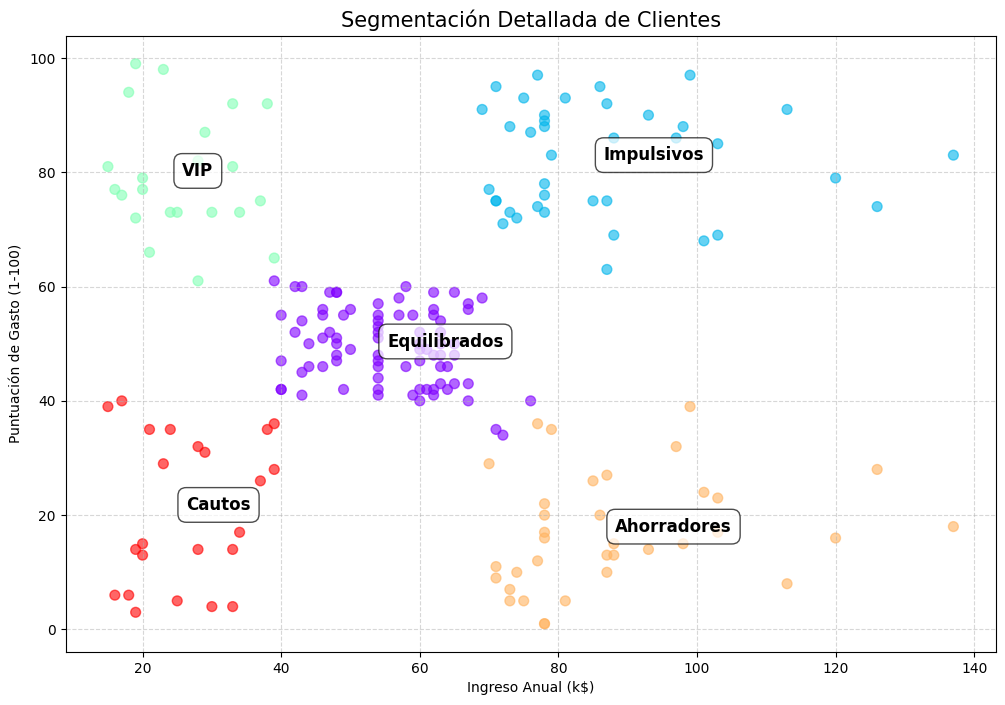

In [53]:
n_clusters_opt = 5 # Asumiendo 5 clusters por el número de perfiles
kmeans_final = KMeans(n_clusters=n_clusters_opt, random_state=42, n_init=10) # Añadido n_init
clusters_real = kmeans_final.fit_predict(X_real)

# 1. Definimos los nombres de los perfiles en el orden de los centroides
nombres_perfiles = [
"Equilibrados",
"Impulsivos",
"VIP",
"Ahorradores",
"Cautos"
]
# 2. Creamos el gráfico base
plt.figure(figsize=(12, 8))
plt.scatter(X_real.iloc[:, 0], X_real.iloc[:, 1], c=clusters_real, s=50, cmap='rainbow', alpha=0.6)
# 3. Obtenemos las coordenadas de los centroides
centros = kmeans_final.cluster_centers_
# 4. En lugar de dibujar una 'X', iteramos para poner el nombre de cada perfil
for i, nombre in enumerate(nombres_perfiles):
  # plt.text(coordenada_x, coordenada_y, texto, estilo...)
  plt.text(centros[i, 0], centros[i, 1], nombre,
  fontsize=12, fontweight='bold', color='black',
  bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.5'))
plt.title('Segmentación Detallada de Clientes', fontsize=15)
plt.xlabel('Ingreso Anual (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##6.- Validación Matemática (Silhouette Score)

In [54]:
#Cerca de 1 = excelente
#Cerca de 0 = superposición
#Negativo = mala agrupación

silhouette_avg = silhouette_score(X_real, clusters_real)
print(f"El puntaje de Silueta para K=5 es: {silhouette_avg:.2f}")

El puntaje de Silueta para K=5 es: 0.55


##7.- Reducción de Dimensionalidad (PCA)

In [55]:
# Creamos una instancia de PCA con 2 componentes principales
pca = PCA(n_components=2)

# Ajustamos PCA a nuestros datos y los transformamos
X_pca = pca.fit_transform(X_real)

print("Datos transformados con PCA exitosamente.")

Datos transformados con PCA exitosamente.


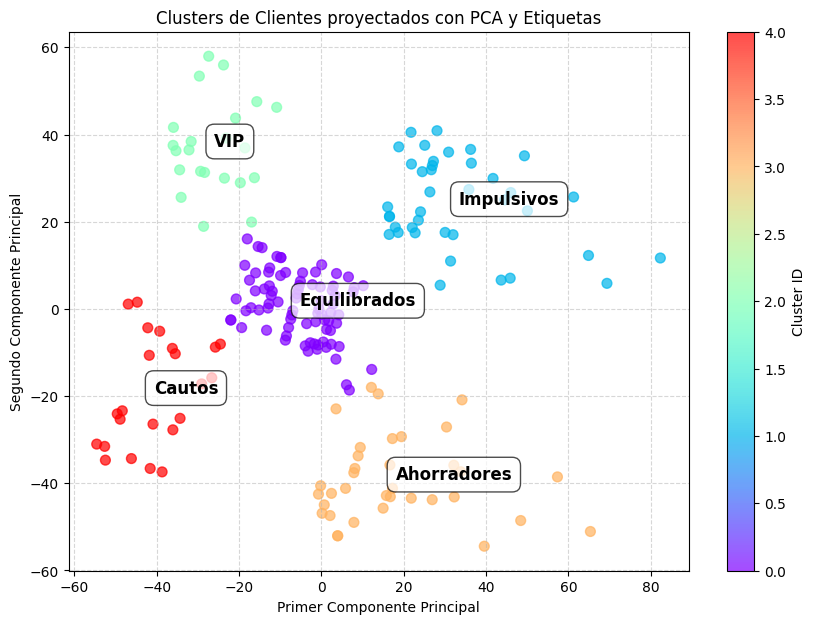

In [56]:
nombres_perfiles = [
"Equilibrados",
"Impulsivos",
"VIP",
"Ahorradores",
"Cautos"
]


centros_pca = []
for i in range(len(nombres_perfiles)):
    cluster_points = X_pca[clusters_real == i]
    centroid = cluster_points.mean(axis=0)
    centros_pca.append(centroid)
centros_pca = np.array(centros_pca)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_real, cmap='rainbow', s=50, alpha=0.7)

for i, nombre in enumerate(nombres_perfiles):
    plt.text(centros_pca[i, 0], centros_pca[i, 1], nombre,
             fontsize=12, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.5'))

plt.title('Clusters de Clientes proyectados con PCA y Etiquetas')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.colorbar(label='Cluster ID')
plt.show()